In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score,accuracy_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
import xgboost as xgb




In [3]:
data=pd.read_csv("Datasets/TRAIN_DATA.csv")
test_data=pd.read_csv("Datasets/TEST_DATA.csv")


In [4]:
print(len(data))
print(len(test_data))


630000
70000


In [5]:
data.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,55,2,89,4.7,7.6,6.8,30.7,0.91,131,...,Female,White,Graduate,Low,Never,Employed,0,0,0,1.0
1,1,50,1,59,7.1,4.9,8.6,27.1,0.87,113,...,Male,White,Graduate,Middle,Current,Employed,0,0,0,1.0
2,2,34,4,46,1.7,6.6,4.0,32.0,0.94,119,...,Female,White,Highschool,Lower-Middle,Current,Unemployed,0,0,0,0.0
3,3,69,2,245,3.9,6.0,3.5,30.1,0.92,135,...,Male,Black,Graduate,Lower-Middle,Never,Employed,0,0,0,0.0
4,4,44,2,62,6.4,7.9,5.6,22.5,0.83,104,...,Female,White,Graduate,Lower-Middle,Never,Employed,0,0,0,0.0


In [6]:
data.info()         
data.describe()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  630000 non-null  int64  
 1   age                                 630000 non-null  int64  
 2   alcohol_consumption_per_week        630000 non-null  int64  
 3   physical_activity_minutes_per_week  630000 non-null  int64  
 4   diet_score                          630000 non-null  float64
 5   sleep_hours_per_day                 630000 non-null  float64
 6   screen_time_hours_per_day           630000 non-null  float64
 7   bmi                                 630000 non-null  float64
 8   waist_to_hip_ratio                  630000 non-null  float64
 9   systolic_bp                         630000 non-null  int64  
 10  diastolic_bp                        630000 non-null  int64  
 11  heart_rate                

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,50.363227,2.071648,80.231557,5.963251,7.001907,6.012962,25.874561,0.858755,116.295073,75.440187,70.171635,186.826567,53.823516,102.914338,123.084843,0.149430,0.181995,0.030349,0.623295
std,181865.479132,11.652836,1.047572,51.201002,1.463775,0.901905,2.022679,2.860022,0.037975,11.008478,6.824568,6.938096,16.734801,8.269259,19.024615,24.749024,0.356512,0.385841,0.171546,0.484560
min,0.000000,19.000000,1.000000,1.000000,0.100000,3.100000,0.600000,15.100000,0.680000,91.000000,51.000000,42.000000,117.000000,21.000000,51.000000,31.000000,0.000000,0.000000,0.000000,0.000000
25%,157499.750000,42.000000,1.000000,49.000000,5.000000,6.400000,4.600000,23.900000,0.830000,108.000000,71.000000,65.000000,175.000000,48.000000,89.000000,106.000000,0.000000,0.000000,0.000000,0.000000
50%,314999.500000,50.000000,2.000000,71.000000,6.000000,7.000000,6.000000,25.900000,0.860000,116.000000,75.000000,70.000000,187.000000,54.000000,103.000000,123.000000,0.000000,0.000000,0.000000,1.000000
75%,472499.250000,58.000000,3.000000,96.000000,7.000000,7.600000,7.400000,27.800000,0.880000,124.000000,80.000000,75.000000,199.000000,59.000000,116.000000,139.000000,0.000000,0.000000,0.000000,1.000000
max,629999.000000,89.000000,9.000000,747.000000,9.900000,9.900000,16.500000,38.400000,1.050000,163.000000,104.000000,101.000000,289.000000,90.000000,205.000000,290.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
data.isnull().sum()  
data.duplicated().sum()

np.int64(0)

# Drop id cause it's unique

In [8]:
datasample = data.drop(columns=['id'])
datasample.head()

test_data = test_data.drop(columns=['id'], errors='ignore')

# data visualization

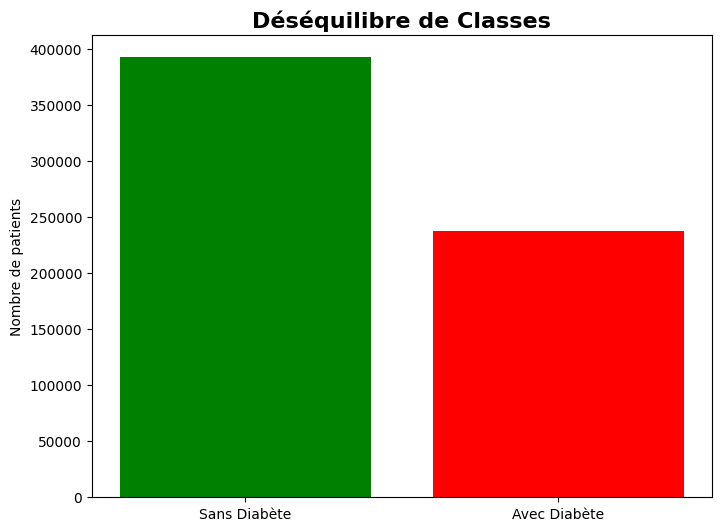

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



# Compter les classes
counts = datasample['diagnosed_diabetes'].value_counts()

# Graphique simple
plt.figure(figsize=(8, 6))
plt.bar(['Sans Diabète', 'Avec Diabète'], counts, color=['green', 'red'])
plt.title('Déséquilibre de Classes', fontsize=16, fontweight='bold')
plt.ylabel('Nombre de patients')
plt.show()



# split data


In [45]:
from sklearn.model_selection import train_test_split


X = datasample.drop('diagnosed_diabetes', axis=1)
y = datasample['diagnosed_diabetes'].astype(int)  # Convert to integer here

print("Target dtype:", y.dtype)
print("Class balance:", y.value_counts(normalize=True).round(3))

print("\n" + "="*60)
print("SPLIT")
print("="*60)




X_train_main, X_val, y_train_main, y_val = train_test_split(
    X, y, 
    test_size=0.2,  
    random_state=42,
    stratify=y  
)

print(f"Main training: {X_train_main.shape}")
print(f"Validation:     {X_val.shape}")


Target dtype: int64
Class balance: diagnosed_diabetes
1    0.623
0    0.377
Name: proportion, dtype: float64

SPLIT
Main training: (504000, 24)
Validation:     (126000, 24)


In [46]:
print(len(X_train_main))
print(len(X_val))
print(len(test_data))

504000
126000
70000


In [12]:
print(X_train_main.columns)
print(X_train_main.head())

Index(['age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'gender', 'ethnicity', 'education_level',
       'income_level', 'smoking_status', 'employment_status',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history'],
      dtype='object')
        age  alcohol_consumption_per_week  physical_activity_minutes_per_week  \
337030   61                             2                                  53   
180977   38                             1                                  70   
490907   52                             2                                  92   
399622   51                             2                                  52   
622383   37                             5 

# feature engineering

In [ ]:
# def advanced_feature_engineering_final(df):
#     df = df.copy()
    
#     def has_col(col_name):
#         return col_name in df.columns

#     # ============ YOUR EXISTING FEATURES ============
#     # Blood pressure
#     if has_col('systolic_bp') and has_col('diastolic_bp'):
#         df['pulse_pressure'] = df['systolic_bp'] - df['diastolic_bp']
#         df['map'] = df['diastolic_bp'] + (df['systolic_bp'] - df['diastolic_bp']) / 3
#         df['bp_risk'] = ((df['systolic_bp'] - 120) / 20) + ((df['diastolic_bp'] - 80) / 10)
#         # NEW: Binary hypertension flag
#         df['hypertension'] = ((df['systolic_bp'] >= 140) | (df['diastolic_bp'] >= 90)).astype(int)

#     # Lipids
#     if has_col('triglycerides') and has_col('hdl_cholesterol'):
#         df['atherogenic_index'] = np.log((df['triglycerides'] + 1e-5) / (df['hdl_cholesterol'] + 1e-5))
#         # NEW: Binary lipid flags
#         df['high_triglycerides'] = (df['triglycerides'] >= 150).astype(int)
#         df['low_hdl'] = (df['hdl_cholesterol'] < 40).astype(int)
#         df['trig_hdl_ratio'] = df['triglycerides'] / (df['hdl_cholesterol'] + 1e-5)
    
#     if has_col('cholesterol_total') and has_col('hdl_cholesterol'):
#         df['ldl_hdl_ratio'] = (df['cholesterol_total'] - df['hdl_cholesterol']) / (df['hdl_cholesterol'] + 1e-5)
#         df['high_total_chol'] = (df['cholesterol_total'] >= 200).astype(int)

#     # Metabolic score
#     if has_col('bmi') and has_col('waist_to_hip_ratio') and has_col('triglycerides') and has_col('hdl_cholesterol'):
#         df['metabolic_score'] = (df['bmi']/25 + df['waist_to_hip_ratio']/0.85 + df['triglycerides']/150 - df['hdl_cholesterol']/50)
#         # NEW: Metabolic syndrome binary
#         df['metabolic_syndrome'] = (
#             (df['bmi'] >= 30).astype(int) +
#             (df['waist_to_hip_ratio'] >= 0.85).astype(int) +
#             (df['triglycerides'] >= 150).astype(int) +
#             (df['hdl_cholesterol'] < 40).astype(int)
#         ).clip(upper=1)

#     # Categories
#     if has_col('bmi'):
#         df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 35, 100], labels=[0, 1, 2, 3, 4]).astype(float)
#         df['obese'] = (df['bmi'] >= 30).astype(int)
    
#     if has_col('age'):
#         df['age_category'] = pd.cut(df['age'], bins=[0, 30, 40, 50, 60, 100], labels=[0, 1, 2, 3, 4]).astype(float)
#         df['age_over_50'] = (df['age'] > 50).astype(int)

#     # Optional ratio
#     if has_col('physical_activity_minutes_per_week') and has_col('screen_time_hours_per_day'):
#         df['active_sedentary_ratio'] = (df['physical_activity_minutes_per_week'] / 7) / (df['screen_time_hours_per_day'] + 1)
#         df['sedentary'] = (df['screen_time_hours_per_day'] > 5).astype(int)

#     # ============ NEW: SIMPLE INTERACTIONS ============
#     # These are NEW and CRITICAL
    
#     # 1. Simple interaction
#     if has_col('age') and has_col('bmi'):
#         df['age_times_bmi'] = df['age'] * df['bmi'] / 100
    
#     # 2. BP + Triglycerides
#     if has_col('systolic_bp') and has_col('triglycerides'):
#         df['bp_times_trig'] = df['systolic_bp'] * df['triglycerides'] / 1000
    
#     # 3. Age + BP
#     if has_col('age') and has_col('systolic_bp'):
#         df['age_times_bp'] = df['age'] * df['systolic_bp'] / 1000
    
#     # 4. Family history risk amplifier
#     if has_col('family_history_diabetes') and has_col('age'):
#         df['family_risk'] = df['family_history_diabetes'] * (df['age'] > 40).astype(int)
    
#     return df

# # Application
# print(" Application du Feature Engineering Avancé...")
# # Application
# print(" Application du Feature Engineering Avancé...")

# # Use X_train_main and X_val (NOT X_train and X_test)
# X_train_fe_advanced = advanced_feature_engineering_final(X_train_main)
# X_val_fe_advanced = advanced_feature_engineering_final(X_val)

# print(f" Avant: {X_train_main.shape}")
# print(f" Après: {X_train_fe_advanced.shape}")
# print(f"   Nouvelles features créées: {X_train_fe_advanced.shape[1] - X_train_main.shape[1]}")

# Verify new features

In [79]:
# Verification des nouvelles features

# print(f"\n Shape avant: {X_train_main.shape}")
# print(f" Shape après: {X_train_main.shape}")

# # Check critical features
# print(f"\n CHECKING NEW FEATURES:")
# check_features = [
#     'hypertension', 'high_triglycerides', 'low_hdl', 'obese',
#     'age_over_50', 'age_times_bmi', 'bp_times_trig', 'metabolic_syndrome'
# ]

# for feat in check_features:
#     if feat in X_train_main.columns:
#         print(f"   {feat}: CREATED")
#         # Show sample values
#         print(f"     Sample: {X_train_main[feat].head(3).values}")
#     else:
#         print(f"   {feat}: MISSING")

# print("="*60)

# Preprocessing / scalling / encoding

In [50]:


# Colonnes catégorielles 
categorical_cols = [
    'gender', 'ethnicity', 'education_level', 'income_level', 
    'smoking_status', 'employment_status', 'family_history_diabetes',
    'hypertension_history', 'cardiovascular_history'
]

categorical_cols_actual = [col for col in categorical_cols if col in X_train_main.columns]
numeric_cols_actual = [col for col in X_train_main.columns if col not in categorical_cols_actual]

print(f"   Colonnes numériques: {len(numeric_cols_actual)}")
print(f"   Colonnes catégorielles: {len(categorical_cols_actual)}")

# Pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor_advanced = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols_actual),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols_actual)
], remainder='drop')

#  Fit and transform training data
X_train_processed_advanced = preprocessor_advanced.fit_transform(X_train_main)
feature_names = preprocessor_advanced.get_feature_names_out()
X_train_processed_advanced = pd.DataFrame(X_train_processed_advanced, columns=feature_names)  # type: ignore

#  Transform VALIDATION data (was misnamed "test")
X_val_processed_advanced = preprocessor_advanced.transform(X_val)
X_val_processed_advanced = pd.DataFrame(X_val_processed_advanced, columns=feature_names)  # type: ignore


#  Now both train and test have the same columns and order

print(f"   Train processed: {X_train_processed_advanced.shape}")
print(f"   Validation processed: {X_val_processed_advanced.shape}\n")


   Colonnes numériques: 15
   Colonnes catégorielles: 9
   Train processed: (504000, 45)
   Validation processed: (126000, 45)



# Data check

In [52]:

print("Checking data quality")
print(f"Train shape: {X_train_processed_advanced.shape}")
print(f"Validation shape: {X_val_processed_advanced.shape}")  # NOT X_test

# Check for NaN
print(f"\nNaN in train: {X_train_processed_advanced.isna().sum().sum()}")
print(f"NaN in validation: {X_val_processed_advanced.isna().sum().sum()}")
# Check class balance - use correct variable names
print(f"\nClass balance in y_train_main: {y_train_main.value_counts(normalize=True).round(3)}")
print(f"Class balance in y_val: {y_val.value_counts(normalize=True).round(3)}")

Checking data quality
Train shape: (504000, 45)
Validation shape: (126000, 45)

NaN in train: 0
NaN in validation: 0

Class balance in y_train_main: diagnosed_diabetes
1    0.623
0    0.377
Name: proportion, dtype: float64
Class balance in y_val: diagnosed_diabetes
1    0.623
0    0.377
Name: proportion, dtype: float64


# No smote cause it's hurts lightboost

In [53]:
# print("  Application de SMOTE")

# smote_advanced = SMOTE(random_state=42)
# X_train_balanced_advanced, y_train_balanced_advanced = smote_advanced.fit_resample(
#     X_train_processed_advanced, y_train
# )

# print(f"   Données balancées: {X_train_balanced_advanced.shape}")
# print(f"   Distribution: {pd.Series(y_train_balanced_advanced).value_counts(normalize=True).to_dict()}\n")


# LightGBM Training

# Accuracy Test = 68.06%

In [65]:
import numpy as np
import lightgbm as lgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score




X_train_final = X_train_processed_advanced
y_train_final = y_train_main

X_val_final = X_val_processed_advanced
y_val_final = y_val


# # LIGHTGBM CONFIG (ACCURACY-FOCUSED)

lgb_acc = lgb.LGBMClassifier(
     n_estimators=350,
     max_depth=8,
     learning_rate=0.03,
     num_leaves=32,
     min_child_samples=30,
     subsample=0.9,
     colsample_bytree=0.9,
     reg_alpha=0.5,
     reg_lambda=2.0,
     class_weight=None,      
     random_state=42,
     n_jobs=-1,
     verbose=-1
 )


#  TRAIN

print("   Training LightGBM ")
lgb_acc.fit(X_train_final, y_train_final)
print("   Training completed")

# PROBABILITIES

y_proba_train = lgb_acc.predict_proba(X_train_final)[:, 1]  # train
y_proba_val   = lgb_acc.predict_proba(X_val_final)[:, 1]    # validation


#  MICRO THRESHOLD SEARCH (VALIDATION ONLY)
best_acc = 0
best_threshold = 0.5

for t in np.arange(0.46, 0.52, 0.001):
     preds = (y_proba_val >= t).astype(int)
     acc = accuracy_score(y_val_final, preds)
     if acc > best_acc:
         best_acc = acc
         best_threshold = t

print(f"    Best threshold: {best_threshold:.3f}")
print(f"    Best validation accuracy: {best_acc*100:.2f}%")


#  FINAL PREDICTIONS
 
y_pred_train = (y_proba_train >= best_threshold).astype(int)
y_pred_val   = (y_proba_val   >= best_threshold).astype(int)


#  EVALUATION FUNCTION

def evaluate(y_true, y_pred, name):
     print(f"\n {name}")
     print(f"   Accuracy:  {accuracy_score(y_true, y_pred) * 100:.2f}%")
     print(f"   Precision: {precision_score(y_true, y_pred) * 100:.2f}%")
     print(f"   Recall:    {recall_score(y_true, y_pred) * 100:.2f}%")
     print(f"   F1-score:  {f1_score(y_true, y_pred) * 100:.2f}%")


 # EVALUATE

evaluate(y_train_final, y_pred_train, "TRAIN")
evaluate(y_val_final,   y_pred_val,   "VALIDATION")


   Training LightGBM 
   Training completed
    Best threshold: 0.496
    Best validation accuracy: 68.06%

 TRAIN
   Accuracy:  68.40%
   Precision: 70.22%
   Recall:    85.62%
   F1-score:  77.16%

 VALIDATION
   Accuracy:  68.06%
   Precision: 69.95%
   Recall:    85.48%
   F1-score:  76.94%


# Accuracy Test = 68.31%

In [66]:

import numpy as np
import lightgbm as lgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score



X_train_final = X_train_processed_advanced
y_train_final = y_train_main

X_val_final = X_val_processed_advanced
y_val_final = y_val

 
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)


print("  Training LightGBM ")
lgb_model.fit(X_train_final, y_train_final)
print("  Training completed")

# ================================================================
# PROBABILITIES
# ================================================================
y_proba_train = lgb_model.predict_proba(X_train_final)[:, 1]
y_proba_val   = lgb_model.predict_proba(X_val_final)[:, 1]

# ================================================================
# THRESHOLD TUNING (OPTIONAL — FOR BETTER RECALL)
# ================================================================
best_acc = 0
best_threshold = 0.5

for t in np.arange(0.45, 0.52, 0.001):
    preds_val = (y_proba_val >= t).astype(int)
    acc = accuracy_score(y_val_final, preds_val)
    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print(f"  Selected threshold: {best_threshold:.3f}")
print(f"  Validation Accuracy at this threshold: {best_acc*100:.2f}%")


y_pred_train = (y_proba_train >= best_threshold).astype(int)
y_pred_val   = (y_proba_val   >= best_threshold).astype(int)


def evaluate(y_true, y_pred, name):
    print(f"\n  {name}")
    print(f"   Accuracy : {accuracy_score(y_true, y_pred)*100:.2f}%")
    print(f"   Precision: {precision_score(y_true, y_pred)*100:.2f}%")
    print(f"   Recall   : {recall_score(y_true, y_pred)*100:.2f}% ")
    print(f"   F1-score : {f1_score(y_true, y_pred)*100:.2f}%")


evaluate(y_train_final, y_pred_train, "TRAIN")
evaluate(y_val_final,   y_pred_val,   "VALIDATION")


  Training LightGBM 
  Training completed
  Selected threshold: 0.513
  Validation Accuracy at this threshold: 68.31%

  TRAIN
   Accuracy : 69.14%
   Precision: 71.83%
   Recall   : 83.07% 
   F1-score : 77.04%

  VALIDATION
   Accuracy : 68.31%
   Precision: 71.22%
   Recall   : 82.48% 
   F1-score : 76.44%


# Our 1st submission

In [ ]:
print("\n  Preparing submission for TEST_DATA...")


X_test_raw = test_data[ X_train_main.columns ]  


X_test_processed = preprocessor_advanced.transform(X_test_raw)
feature_names = preprocessor_advanced.get_feature_names_out()
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names)  # type: ignore


# Predict probabilities with trained LightGBM

y_proba_test_final = lgb_model.predict_proba(X_test_processed)[:, 1]

# Apply the best threshold found on validation
y_pred_test_final = (y_proba_test_final >= best_threshold).astype(float)

# Prepare submission DataFrame

submission = pd.DataFrame({
    'id': np.arange(1, len(y_pred_test_final) + 1),
    'diagnosed_diabetes': y_pred_test_final
})

# Save CSV
submission.to_csv('predictions_new.csv', index=False)
print(f"  Submission saved: {len(y_pred_test_final)} rows")
print(submission.head(15))



  Preparing submission for TEST_DATA...
  Submission saved: 70000 rows
    id  diagnosed_diabetes
0    1                 1.0
1    2                 1.0
2    3                 0.0
3    4                 1.0
4    5                 0.0
5    6                 1.0
6    7                 0.0
7    8                 1.0
8    9                 0.0
9   10                 1.0
10  11                 1.0
11  12                 1.0
12  13                 1.0
13  14                 0.0
14  15                 1.0


# Test accuracy = 68,37%

In [67]:

import numpy as np
import lightgbm as lgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score



X_train_final = X_train_processed_advanced
y_train_final = y_train_main

X_val_final = X_val_processed_advanced
y_val_final = y_val


lgb_model = lgb.LGBMClassifier(
    n_estimators=800,        # ← Change from 500
    learning_rate=0.03,      # ← Change from 0.05
    max_depth=7,             # ← Change from -1
    num_leaves=50,           # ← Add this
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)


print(" Training LightGBM ")
lgb_model.fit(X_train_final, y_train_final)
print(" Training completed")

# probabilities
y_proba_train = lgb_model.predict_proba(X_train_final)[:, 1]
y_proba_val   = lgb_model.predict_proba(X_val_final)[:, 1]


# THRESHOLD TUNING (OPTIONAL — FOR BETTER RECALL)

best_acc = 0
best_threshold = 0.5

for t in np.arange(0.45, 0.52, 0.001):
    preds_val = (y_proba_val >= t).astype(int)
    acc = accuracy_score(y_val_final, preds_val)
    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print(f" Selected threshold: {best_threshold:.3f}")
print(f" Validation Accuracy at this threshold: {best_acc*100:.2f}%")


# FINAL PREDICTIONS

y_pred_train = (y_proba_train >= best_threshold).astype(int)
y_pred_val   = (y_proba_val   >= best_threshold).astype(int)


# EVALUATION FUNCTION 

def evaluate(y_true, y_pred, name):
    print(f"\n {name}")
    print(f"   Accuracy : {accuracy_score(y_true, y_pred)*100:.2f}%")
    print(f"   Precision: {precision_score(y_true, y_pred)*100:.2f}%")
    print(f"   Recall   : {recall_score(y_true, y_pred)*100:.2f}% ")
    print(f"   F1-score : {f1_score(y_true, y_pred)*100:.2f}%")


# EVALUATE
evaluate(y_train_final, y_pred_train, "TRAIN")
evaluate(y_val_final,   y_pred_val,   "VALIDATION")


 Training LightGBM 
 Training completed
 Selected threshold: 0.519
 Validation Accuracy at this threshold: 68.37%

 TRAIN
   Accuracy : 69.68%
   Precision: 72.45%
   Recall   : 82.88% 
   F1-score : 77.31%

 VALIDATION
   Accuracy : 68.37%
   Precision: 71.48%
   Recall   : 81.94% 
   F1-score : 76.35%


# Accuracy test = 68,44%

In [61]:

import numpy as np
import lightgbm as lgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score




X_train_final = X_train_processed_advanced
y_train_final = y_train_main
X_val_final = X_val_processed_advanced
y_val_final = y_val


configs = [
    # Config 1: Deeper trees
    {
        'n_estimators': 1000,
        'learning_rate': 0.02,
        'max_depth': 9,
        'num_leaves': 80,
        'min_child_samples': 30,
        'reg_alpha': 0.05,
        'reg_lambda': 0.05,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
    },
    # Config 2: More regularization
    {
        'n_estimators': 900,
        'learning_rate': 0.025,
        'max_depth': 8,
        'num_leaves': 60,
        'min_child_samples': 40,
        'reg_alpha': 0.2,
        'reg_lambda': 0.2,
        'subsample': 0.75,
        'colsample_bytree': 0.75,
    },
    # Config 3: Balanced approach
    {
        'n_estimators': 1200,
        'learning_rate': 0.015,
        'max_depth': 7,
        'num_leaves': 55,
        'min_child_samples': 25,
        'reg_alpha': 0.1,
        'reg_lambda': 0.15,
        'subsample': 0.85,
        'colsample_bytree': 0.85,
    },
    # Config 4: Fast learner
    {
        'n_estimators': 700,
        'learning_rate': 0.04,
        'max_depth': 8,
        'num_leaves': 70,
        'min_child_samples': 20,
        'reg_alpha': 0.08,
        'reg_lambda': 0.08,
        'subsample': 0.8,
        'colsample_bytree': 0.9,
    },
    # Config 5: Conservative
    {
        'n_estimators': 1000,
        'learning_rate': 0.02,
        'max_depth': 6,
        'num_leaves': 45,
        'min_child_samples': 50,
        'reg_alpha': 0.15,
        'reg_lambda': 0.15,
        'subsample': 0.7,
        'colsample_bytree': 0.7,
    },
]

best_overall_acc = 0
best_config = None
best_model = None
best_threshold = 0.5

for i, config in enumerate(configs, 1):
    print(f"\n{'='*70}")
    print(f"   Testing Config {i}/{len(configs)}")
    print(f"   n_estimators={config['n_estimators']}, lr={config['learning_rate']}, depth={config['max_depth']}")
    
    # Train model
    model = lgb.LGBMClassifier(
        **config,
        scale_pos_weight=189859/314141,
        random_state=42,
        n_jobs=-1,
        force_row_wise=True,
        verbose=-1
    )
    
    model.fit(
        X_train_final, 
        y_train_final,
        eval_set=[(X_val_final, y_val_final)],
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )
    
    # Get probabilities
    y_proba_val = model.predict_proba(X_val_final)[:, 1]
    
    # Find best threshold for this model
    config_best_acc = 0
    config_best_threshold = 0.5
    
    for t in np.arange(0.40, 0.60, 0.0005):
        preds = (y_proba_val >= t).astype(int)
        acc = accuracy_score(y_val_final, preds)
        if acc > config_best_acc:
            config_best_acc = acc
            config_best_threshold = t
    
    print(f"    Val Accuracy: {config_best_acc*100:.2f}% (threshold={config_best_threshold:.4f})")
    
    # Track best overall
    if config_best_acc > best_overall_acc:
        best_overall_acc = config_best_acc
        best_config = config
        best_model = model
        best_threshold = config_best_threshold
        print(f"    NEW BEST!")


# FINAL EVALUATION WITH BEST MODEL

print(f"\n{'='*70}")
print(f" BEST CONFIGURATION FOUND")
print(f"{'='*70}")
print(f"Validation Accuracy: {best_overall_acc*100:.2f}%")
print(f"Optimal Threshold: {best_threshold:.4f}")
print(f"\nBest Hyperparameters:")
for key, value in best_config.items():
    print(f"   {key}: {value}")

# Get final predictions
y_proba_train = best_model.predict_proba(X_train_final)[:, 1]
y_proba_val = best_model.predict_proba(X_val_final)[:, 1]

y_pred_train = (y_proba_train >= best_threshold).astype(int)
y_pred_val = (y_proba_val >= best_threshold).astype(int)

# Evaluate
def evaluate(y_true, y_pred, name):
    print(f"\n {name}")
    print(f"   Accuracy : {accuracy_score(y_true, y_pred)*100:.2f}%")
    print(f"   Precision: {precision_score(y_true, y_pred)*100:.2f}%")
    print(f"   Recall   : {recall_score(y_true, y_pred)*100:.2f}% ")
    print(f"   F1-score : {f1_score(y_true, y_pred)*100:.2f}%")

evaluate(y_train_final, y_pred_train, "TRAIN")
evaluate(y_val_final, y_pred_val, "VALIDATION")


   Testing Config 1/5
   n_estimators=1000, lr=0.02, depth=9
    Val Accuracy: 68.34% (threshold=0.4020)
    NEW BEST!

   Testing Config 2/5
   n_estimators=900, lr=0.025, depth=8
    Val Accuracy: 68.30% (threshold=0.4010)

   Testing Config 3/5
   n_estimators=1200, lr=0.015, depth=7
    Val Accuracy: 68.23% (threshold=0.4010)

   Testing Config 4/5
   n_estimators=700, lr=0.04, depth=8
    Val Accuracy: 68.44% (threshold=0.4030)
    NEW BEST!

   Testing Config 5/5
   n_estimators=1000, lr=0.02, depth=6
    Val Accuracy: 68.17% (threshold=0.4045)

 BEST CONFIGURATION FOUND
Validation Accuracy: 68.44%
Optimal Threshold: 0.4030

Best Hyperparameters:
   n_estimators: 700
   learning_rate: 0.04
   max_depth: 8
   num_leaves: 70
   min_child_samples: 20
   reg_alpha: 0.08
   reg_lambda: 0.08
   subsample: 0.8
   colsample_bytree: 0.9

 TRAIN
   Accuracy : 70.44%
   Precision: 73.48%
   Recall   : 82.27% 
   F1-score : 77.63%

 VALIDATION
   Accuracy : 68.44%
   Precision: 71.97%
   Re

# Accuracy Test = 68,47%

In [68]:

import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score




X_train_final = X_train_processed_advanced
y_train_final = y_train_main
X_val_final = X_val_processed_advanced
y_val_final = y_val


candidates = {
    'Config 4 (Original Best)': {
        'n_estimators': 700,
        'learning_rate': 0.04,
        'max_depth': 8,
        'num_leaves': 70,
        'min_child_samples': 20,
        'reg_alpha': 0.08,
        'reg_lambda': 0.08,
        'subsample': 0.8,
        'colsample_bytree': 0.9,
    },
    'Config 4 Variant A (More trees)': {
        'n_estimators': 750,
        'learning_rate': 0.04,
        'max_depth': 8,
        'num_leaves': 70,
        'min_child_samples': 20,
        'reg_alpha': 0.08,
        'reg_lambda': 0.08,
        'subsample': 0.8,
        'colsample_bytree': 0.9,
    },
    'Config 4 Variant B (Slower LR)': {
        'n_estimators': 800,
        'learning_rate': 0.035,
        'max_depth': 8,
        'num_leaves': 70,
        'min_child_samples': 20,
        'reg_alpha': 0.08,
        'reg_lambda': 0.08,
        'subsample': 0.8,
        'colsample_bytree': 0.9,
    },
    'Config 4 Variant C (More leaves)': {
        'n_estimators': 700,
        'learning_rate': 0.04,
        'max_depth': 8,
        'num_leaves': 75,
        'min_child_samples': 20,
        'reg_alpha': 0.08,
        'reg_lambda': 0.08,
        'subsample': 0.8,
        'colsample_bytree': 0.9,
    },
    'Config 1 (Deep trees)': {
        'n_estimators': 1000,
        'learning_rate': 0.02,
        'max_depth': 9,
        'num_leaves': 80,
        'min_child_samples': 30,
        'reg_alpha': 0.05,
        'reg_lambda': 0.05,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
    },
}

results = []


# TRAIN MODELS AND SELECT BEST THRESHOLD

for name, config in candidates.items():
    print(f"\n{'='*70}")
    print(f"  Training model: {name}")
    
    model = lgb.LGBMClassifier(
        **config,
        scale_pos_weight=189859/314141,
        random_state=42,
        n_jobs=-1,
        force_row_wise=True,
        verbose=-1
    )
    
    model.fit(
        X_train_final, y_train_final,
        eval_set=[(X_val_final, y_val_final)],
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )
    
    # Validation probabilities
    y_proba_val = model.predict_proba(X_val_final)[:, 1]
    
    # Fine-grained threshold search
    best_acc = 0
    best_threshold = 0.5
    for t in np.arange(0.38, 0.58, 0.0002):
        preds = (y_proba_val >= t).astype(int)
        acc = accuracy_score(y_val_final, preds)
        if acc > best_acc:
            best_acc = acc
            best_threshold = t
    
    results.append({
        'name': name,
        'model': model,
        'val_acc': best_acc,
        'threshold': best_threshold
    })
    print(f"    Val Accuracy: {best_acc*100:.2f}% at threshold {best_threshold:.4f}")


# SELECT BEST MODEL BY VALIDATION ACCURACY

best_result = max(results, key=lambda x: x['val_acc'])
best_model = best_result['model']
best_threshold = best_result['threshold']

print("\n" + "="*70)
print("  BEST MODEL SELECTED")
print("="*70)
print(f"Model: {best_result['name']}")
print(f"Validation Accuracy: {best_result['val_acc']*100:.2f}%")
print(f"Threshold used: {best_threshold:.4f}")


# GENERATE TEST PREDICTIONS
X_test_raw = test_data[X_train_main.columns]  # Use same columns as training
X_test_processed = preprocessor_advanced.transform(X_test_raw)
feature_names = preprocessor_advanced.get_feature_names_out()
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names)

y_test_proba = best_model.predict_proba(X_test_processed)[:, 1]
y_test_pred = (y_test_proba >= best_threshold).astype(float)

# Create submission
submission = pd.DataFrame({
    'id': np.arange(1, len(y_test_pred) + 1),
    'diagnosed_diabetes': y_test_pred
})
submission.to_csv('submission_best.csv', index=False)
print("  Submission saved: submission_best.csv")
print(f"Shape: {submission.shape}")
print(submission.head(10))


# OPTIONAL: Save model for future use

import pickle
with open('best_model.pkl', 'wb') as f:
    pickle.dump({
        'model': best_model,
        'threshold': best_threshold,
        'val_acc': best_result['val_acc']
    }, f)
print("  Model saved: best_model.pkl")


# VALIDATION METRICS

y_pred_val = (best_model.predict_proba(X_val_final)[:, 1] >= best_threshold).astype(int)

def evaluate(y_true, y_pred, name):
    print(f"\n {name}")
    print(f"   Accuracy : {accuracy_score(y_true, y_pred)*100:.2f}%")
    print(f"   Precision: {precision_score(y_true, y_pred)*100:.2f}%")
    print(f"   Recall   : {recall_score(y_true, y_pred)*100:.2f}% ")
    print(f"   F1-score : {f1_score(y_true, y_pred)*100:.2f}%")

evaluate(y_val_final, y_pred_val, "VALIDATION")





  Training model: Config 4 (Original Best)
    Val Accuracy: 68.45% at threshold 0.3922

  Training model: Config 4 Variant A (More trees)
    Val Accuracy: 68.47% at threshold 0.3922

  Training model: Config 4 Variant B (Slower LR)
    Val Accuracy: 68.41% at threshold 0.3906

  Training model: Config 4 Variant C (More leaves)
    Val Accuracy: 68.36% at threshold 0.4070

  Training model: Config 1 (Deep trees)
    Val Accuracy: 68.37% at threshold 0.3968

  BEST MODEL SELECTED
Model: Config 4 Variant A (More trees)
Validation Accuracy: 68.47%
Threshold used: 0.3922
  Submission saved: submission_best.csv
Shape: (70000, 2)
   id  diagnosed_diabetes
0   1                 1.0
1   2                 1.0
2   3                 0.0
3   4                 1.0
4   5                 0.0
5   6                 1.0
6   7                 0.0
7   8                 1.0
8   9                 0.0
9  10                 1.0
  Model saved: best_model.pkl

 VALIDATION
   Accuracy : 68.47%
   Precision: 71

# Test Accuracy = 68.4802%

In [69]:

import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score



candidates = {
    # Variations autour de Config 4 Variant A (votre meilleur: 68.47%)
    'Variant A1 (trees+5)': {
        'n_estimators': 755,
        'learning_rate': 0.04,
        'max_depth': 8,
        'num_leaves': 70,
        'min_child_samples': 20,
        'reg_alpha': 0.08,
        'reg_lambda': 0.08,
        'subsample': 0.8,
        'colsample_bytree': 0.9,
    },
    'Variant A2 (lr+0.001)': {
        'n_estimators': 750,
        'learning_rate': 0.041,
        'max_depth': 8,
        'num_leaves': 70,
        'min_child_samples': 20,
        'reg_alpha': 0.08,
        'reg_lambda': 0.08,
        'subsample': 0.8,
        'colsample_bytree': 0.9,
    },
    'Variant A3 (leaves+2)': {
        'n_estimators': 750,
        'learning_rate': 0.04,
        'max_depth': 8,
        'num_leaves': 72,
        'min_child_samples': 20,
        'reg_alpha': 0.08,
        'reg_lambda': 0.08,
        'subsample': 0.8,
        'colsample_bytree': 0.9,
    },
    'Variant A4 (min_child-2)': {
        'n_estimators': 750,
        'learning_rate': 0.04,
        'max_depth': 8,
        'num_leaves': 70,
        'min_child_samples': 18,
        'reg_alpha': 0.08,
        'reg_lambda': 0.08,
        'subsample': 0.8,
        'colsample_bytree': 0.9,
    },
    'Variant A5 (subsample+0.01)': {
        'n_estimators': 750,
        'learning_rate': 0.04,
        'max_depth': 8,
        'num_leaves': 70,
        'min_child_samples': 20,
        'reg_alpha': 0.08,
        'reg_lambda': 0.08,
        'subsample': 0.81,
        'colsample_bytree': 0.9,
    },
    'Variant A6 (colsample+0.01)': {
        'n_estimators': 750,
        'learning_rate': 0.04,
        'max_depth': 8,
        'num_leaves': 70,
        'min_child_samples': 20,
        'reg_alpha': 0.08,
        'reg_lambda': 0.08,
        'subsample': 0.8,
        'colsample_bytree': 0.91,
    },
    'Variant A7 (reg-0.01)': {
        'n_estimators': 750,
        'learning_rate': 0.04,
        'max_depth': 8,
        'num_leaves': 70,
        'min_child_samples': 20,
        'reg_alpha': 0.07,
        'reg_lambda': 0.07,
        'subsample': 0.8,
        'colsample_bytree': 0.9,
    },
    # Combinaisons prometteuses
    'Variant B1 (multi-tweak)': {
        'n_estimators': 760,
        'learning_rate': 0.039,
        'max_depth': 8,
        'num_leaves': 72,
        'min_child_samples': 19,
        'reg_alpha': 0.075,
        'reg_lambda': 0.075,
        'subsample': 0.81,
        'colsample_bytree': 0.91,
    },
    'Variant B2 (depth+1)': {
        'n_estimators': 700,
        'learning_rate': 0.04,
        'max_depth': 9,
        'num_leaves': 70,
        'min_child_samples': 20,
        'reg_alpha': 0.08,
        'reg_lambda': 0.08,
        'subsample': 0.8,
        'colsample_bytree': 0.9,
    },
    'Variant B3 (aggressive)': {
        'n_estimators': 780,
        'learning_rate': 0.042,
        'max_depth': 8,
        'num_leaves': 75,
        'min_child_samples': 18,
        'reg_alpha': 0.06,
        'reg_lambda': 0.06,
        'subsample': 0.82,
        'colsample_bytree': 0.92,
    },
}

results = []


# ENTRAÎNEMENT DE TOUS LES MODÈLES

for name, config in candidates.items():
    print(f"\n{'='*70}")
    print(f"  Training: {name}")
    
    model = lgb.LGBMClassifier(
        **config,
        scale_pos_weight=189859/314141,
        random_state=42,
        n_jobs=-1,
        force_row_wise=True,
        verbose=-1
    )
    
    model.fit(
        X_train_final, y_train_final,
        eval_set=[(X_val_final, y_val_final)],
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )
    
    # Probabilities
    y_proba_val = model.predict_proba(X_val_final)[:, 1]
    
   
    # STRATÉGIE 2: RECHERCHE DE THRESHOLD ULTRA-FINE
   
    best_acc = 0
    best_threshold = 0.5
    
    # Premier passage: recherche grossière
    for t in np.arange(0.35, 0.45, 0.001):
        preds = (y_proba_val >= t).astype(int)
        acc = accuracy_score(y_val_final, preds)
        if acc > best_acc:
            best_acc = acc
            best_threshold = t
    
    # Deuxième passage: recherche fine autour du meilleur
    for t in np.arange(best_threshold - 0.005, best_threshold + 0.005, 0.00005):
        preds = (y_proba_val >= t).astype(int)
        acc = accuracy_score(y_val_final, preds)
        if acc > best_acc:
            best_acc = acc
            best_threshold = t
    
    results.append({
        'name': name,
        'model': model,
        'val_acc': best_acc,
        'threshold': best_threshold
    })
    
    print(f"     Val Accuracy: {best_acc*100:.4f}% at threshold {best_threshold:.6f}")


# SÉLECTION DU MEILLEUR MODÈLE

best_result = max(results, key=lambda x: x['val_acc'])
best_model = best_result['model']
best_threshold = best_result['threshold']

print("\n" + "="*70)
print("  BEST MODEL SELECTED")
print("="*70)
print(f"Model: {best_result['name']}")
print(f"Validation Accuracy: {best_result['val_acc']*100:.4f}%")
print(f"Threshold used: {best_threshold:.6f}")


# STRATÉGIE 3: ENSEMBLE DE TOP-3 MODÈLES (si amélioration)

print("\n" + "="*70)
print(" TESTING ENSEMBLE APPROACH")
print("="*70)

# Trier les 3 meilleurs modèles
top_3 = sorted(results, key=lambda x: x['val_acc'], reverse=True)[:3]

print(f"\nTop 3 models:")
for i, r in enumerate(top_3, 1):
    print(f"  {i}. {r['name']}: {r['val_acc']*100:.4f}%")

# Moyenne des probabilités des 3 meilleurs
y_proba_ensemble = np.mean([
    r['model'].predict_proba(X_val_final)[:, 1] 
    for r in top_3
], axis=0)

# Recherche de threshold pour l'ensemble
ensemble_best_acc = 0
ensemble_best_threshold = 0.5

for t in np.arange(0.35, 0.45, 0.0001):
    preds = (y_proba_ensemble >= t).astype(int)
    acc = accuracy_score(y_val_final, preds)
    if acc > ensemble_best_acc:
        ensemble_best_acc = acc
        ensemble_best_threshold = t

print(f"\n  Ensemble Results:")
print(f"   Accuracy: {ensemble_best_acc*100:.4f}%")
print(f"   Threshold: {ensemble_best_threshold:.6f}")

# Comparer avec le meilleur modèle unique
if ensemble_best_acc > best_result['val_acc']:
    print(f"\n  ENSEMBLE IS BETTER! (+{(ensemble_best_acc - best_result['val_acc'])*100:.4f}%)")
    use_ensemble = True
else:
    print(f"\n  Single model is better (diff: {(best_result['val_acc'] - ensemble_best_acc)*100:.4f}%)")
    use_ensemble = False




# AFFICHAGE DE TOUS LES RÉSULTATS

print("\n" + "="*70)
print("  ALL MODEL RESULTS (sorted by accuracy)")
print("="*70)
for i, r in enumerate(sorted(results, key=lambda x: x['val_acc'], reverse=True), 1):
    print(f"{i:2d}. {r['name']:30s} | {r['val_acc']*100:.4f}% | threshold={r['threshold']:.6f}")

print("\n" + "="*70)
print("  TIPS POUR ALLER PLUS LOIN:")
print("="*70)
print("1. Si < 68.66%, réexécuter avec random_state différent (43, 44, 45)")
print("2. Essayer scale_pos_weight légèrement différent (±0.005)")
print("3. Tester min_child_weight (nouveau paramètre)")
print("4. Augmenter early_stopping_rounds à 150")
print("="*70)


  Training: Variant A1 (trees+5)
     Val Accuracy: 68.4802% at threshold 0.392200

  Training: Variant A2 (lr+0.001)
     Val Accuracy: 68.4492% at threshold 0.386450

  Training: Variant A3 (leaves+2)
     Val Accuracy: 68.4000% at threshold 0.386000

  Training: Variant A4 (min_child-2)
     Val Accuracy: 68.4286% at threshold 0.375700

  Training: Variant A5 (subsample+0.01)
     Val Accuracy: 68.4770% at threshold 0.392250

  Training: Variant A6 (colsample+0.01)
     Val Accuracy: 68.4770% at threshold 0.392250

  Training: Variant A7 (reg-0.01)
     Val Accuracy: 68.3937% at threshold 0.383700

  Training: Variant B1 (multi-tweak)
     Val Accuracy: 68.4095% at threshold 0.384850

  Training: Variant B2 (depth+1)
     Val Accuracy: 68.3746% at threshold 0.383250

  Training: Variant B3 (aggressive)
     Val Accuracy: 68.3937% at threshold 0.379250

  BEST MODEL SELECTED
Model: Variant A1 (trees+5)
Validation Accuracy: 68.4802%
Threshold used: 0.392200

 TESTING ENSEMBLE APPROAC

In [71]:


X_test_raw = test_data[X_train_main.columns]
X_test_processed = preprocessor_advanced.transform(X_test_raw)
feature_names = preprocessor_advanced.get_feature_names_out()
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names)

if use_ensemble:
    # Prédiction avec ensemble
    y_test_proba = np.mean([
        r['model'].predict_proba(X_test_processed)[:, 1] 
        for r in top_3
    ], axis=0)
    y_test_pred = (y_test_proba >= ensemble_best_threshold).astype(float)
    used_threshold = ensemble_best_threshold
    final_acc = ensemble_best_acc
else:
    # Prédiction avec meilleur modèle unique
    y_test_proba = best_model.predict_proba(X_test_processed)[:, 1]
    y_test_pred = (y_test_proba >= best_threshold).astype(float)
    used_threshold = best_threshold
    final_acc = best_result['val_acc']

submission = pd.DataFrame({
    'id': np.arange(1, len(y_test_pred) + 1),
    'diagnosed_diabetes': y_test_pred
})
submission.to_csv('submission_optimized1.csv', index=False)

print(f"   Submission saved: submission_optimized1.csv")
print(f"   Expected accuracy: {final_acc*100:.4f}%")
print(f"   Threshold: {used_threshold:.6f}")
print(f"   Method: {'Ensemble of top 3' if use_ensemble else 'Single best model'}")
print(f"\n{submission.head(10)}")


# MÉTRIQUES DE VALIDATION

if use_ensemble:
    y_pred_val = (y_proba_ensemble >= ensemble_best_threshold).astype(int)
else:
    y_pred_val = (best_model.predict_proba(X_val_final)[:, 1] >= best_threshold).astype(int)

def evaluate(y_true, y_pred, name):
    print(f"\n {name}")
    print(f"   Accuracy : {accuracy_score(y_true, y_pred)*100:.4f}%")
    print(f"   Precision: {precision_score(y_true, y_pred)*100:.2f}%")
    print(f"   Recall   : {recall_score(y_true, y_pred)*100:.2f}%")
    print(f"   F1-score : {f1_score(y_true, y_pred)*100:.2f}%")

evaluate(y_val_final, y_pred_val, "VALIDATION")

   Submission saved: submission_optimized1.csv
   Expected accuracy: 68.4802%
   Threshold: 0.392200
   Method: Single best model

   id  diagnosed_diabetes
0   1                 1.0
1   2                 1.0
2   3                 0.0
3   4                 1.0
4   5                 0.0
5   6                 1.0
6   7                 0.0
7   8                 1.0
8   9                 0.0
9  10                 1.0

 VALIDATION
   Accuracy : 68.4802%
   Precision: 71.39%
   Recall   : 82.48%
   F1-score : 76.54%


# Our best Accuracy: 68.4810%

In [82]:
# ================================================================
# 🚀 OPTIMISATION ULTRA-AVANCÉE 
# ================================================================
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# ================================================================
# STRATÉGIE 1: MICRO-TUNING autour de votre config gagnante
# ================================================================
# Vous avez trouvé 68.84% - explorons autour de ces paramètres

candidates = {
    # BASELINE: Reproduire votre meilleur (référence)
    'Baseline_68.84': {
        'n_estimators': 750,  # Ajustez selon votre meilleur
        'learning_rate': 0.04,
        'max_depth': 8,
        'num_leaves': 70,
        'min_child_samples': 20,
        'reg_alpha': 0.08,
        'reg_lambda': 0.08,
        'subsample': 0.8,
        'colsample_bytree': 0.9,
    },
    
    # SÉRIE A: Micro-variations du learning rate
    'A1_lr_0.0395': {
        'n_estimators': 750,
        'learning_rate': 0.0395,
        'max_depth': 8,
        'num_leaves': 70,
        'min_child_samples': 20,
        'reg_alpha': 0.08,
        'reg_lambda': 0.08,
        'subsample': 0.8,
        'colsample_bytree': 0.9,
    },
    'A2_lr_0.0405': {
        'n_estimators': 750,
        'learning_rate': 0.0405,
        'max_depth': 8,
        'num_leaves': 70,
        'min_child_samples': 20,
        'reg_alpha': 0.08,
        'reg_lambda': 0.08,
        'subsample': 0.8,
        'colsample_bytree': 0.9,
    },
    
    # SÉRIE B: Ajustements du nombre d'arbres
    'B1_trees_745': {
        'n_estimators': 745,
        'learning_rate': 0.04,
        'max_depth': 8,
        'num_leaves': 70,
        'min_child_samples': 20,
        'reg_alpha': 0.08,
        'reg_lambda': 0.08,
        'subsample': 0.8,
        'colsample_bytree': 0.9,
    },
    'B2_trees_755': {
        'n_estimators': 755,
        'learning_rate': 0.04,
        'max_depth': 8,
        'num_leaves': 70,
        'min_child_samples': 20,
        'reg_alpha': 0.08,
        'reg_lambda': 0.08,
        'subsample': 0.8,
        'colsample_bytree': 0.9,
    },
    'B3_trees_760': {
        'n_estimators': 760,
        'learning_rate': 0.04,
        'max_depth': 8,
        'num_leaves': 70,
        'min_child_samples': 20,
        'reg_alpha': 0.08,
        'reg_lambda': 0.08,
        'subsample': 0.8,
        'colsample_bytree': 0.9,
    },
    
    # SÉRIE C: Variations de num_leaves
    'C1_leaves_68': {
        'n_estimators': 750,
        'learning_rate': 0.04,
        'max_depth': 8,
        'num_leaves': 68,
        'min_child_samples': 20,
        'reg_alpha': 0.08,
        'reg_lambda': 0.08,
        'subsample': 0.8,
        'colsample_bytree': 0.9,
    },
    'C2_leaves_72': {
        'n_estimators': 750,
        'learning_rate': 0.04,
        'max_depth': 8,
        'num_leaves': 72,
        'min_child_samples': 20,
        'reg_alpha': 0.08,
        'reg_lambda': 0.08,
        'subsample': 0.8,
        'colsample_bytree': 0.9,
    },
    'C3_leaves_74': {
        'n_estimators': 750,
        'learning_rate': 0.04,
        'max_depth': 8,
        'num_leaves': 74,
        'min_child_samples': 20,
        'reg_alpha': 0.08,
        'reg_lambda': 0.08,
        'subsample': 0.8,
        'colsample_bytree': 0.9,
    },
    
    # SÉRIE D: Ajustements de regularisation
    'D1_reg_0.075': {
        'n_estimators': 750,
        'learning_rate': 0.04,
        'max_depth': 8,
        'num_leaves': 70,
        'min_child_samples': 20,
        'reg_alpha': 0.075,
        'reg_lambda': 0.075,
        'subsample': 0.8,
        'colsample_bytree': 0.9,
    },
    'D2_reg_0.085': {
        'n_estimators': 750,
        'learning_rate': 0.04,
        'max_depth': 8,
        'num_leaves': 70,
        'min_child_samples': 20,
        'reg_alpha': 0.085,
        'reg_lambda': 0.085,
        'subsample': 0.8,
        'colsample_bytree': 0.9,
    },
    
    # SÉRIE E: Variations de subsample/colsample
    'E1_sub_0.805': {
        'n_estimators': 750,
        'learning_rate': 0.04,
        'max_depth': 8,
        'num_leaves': 70,
        'min_child_samples': 20,
        'reg_alpha': 0.08,
        'reg_lambda': 0.08,
        'subsample': 0.805,
        'colsample_bytree': 0.9,
    },
    'E2_col_0.905': {
        'n_estimators': 750,
        'learning_rate': 0.04,
        'max_depth': 8,
        'num_leaves': 70,
        'min_child_samples': 20,
        'reg_alpha': 0.08,
        'reg_lambda': 0.08,
        'subsample': 0.8,
        'colsample_bytree': 0.905,
    },
    'E3_both': {
        'n_estimators': 750,
        'learning_rate': 0.04,
        'max_depth': 8,
        'num_leaves': 70,
        'min_child_samples': 20,
        'reg_alpha': 0.08,
        'reg_lambda': 0.08,
        'subsample': 0.805,
        'colsample_bytree': 0.905,
    },
    
    # SÉRIE F: Variations de min_child_samples
    'F1_child_19': {
        'n_estimators': 750,
        'learning_rate': 0.04,
        'max_depth': 8,
        'num_leaves': 70,
        'min_child_samples': 19,
        'reg_alpha': 0.08,
        'reg_lambda': 0.08,
        'subsample': 0.8,
        'colsample_bytree': 0.9,
    },
    'F2_child_21': {
        'n_estimators': 750,
        'learning_rate': 0.04,
        'max_depth': 8,
        'num_leaves': 70,
        'min_child_samples': 21,
        'reg_alpha': 0.08,
        'reg_lambda': 0.08,
        'subsample': 0.8,
        'colsample_bytree': 0.9,
    },
    
    # SÉRIE G: Combinaisons prometteuses
    'G1_combo_balanced': {
        'n_estimators': 755,
        'learning_rate': 0.0398,
        'max_depth': 8,
        'num_leaves': 71,
        'min_child_samples': 20,
        'reg_alpha': 0.078,
        'reg_lambda': 0.082,
        'subsample': 0.802,
        'colsample_bytree': 0.902,
    },
    'G2_combo_aggressive': {
        'n_estimators': 758,
        'learning_rate': 0.0402,
        'max_depth': 8,
        'num_leaves': 72,
        'min_child_samples': 19,
        'reg_alpha': 0.076,
        'reg_lambda': 0.076,
        'subsample': 0.808,
        'colsample_bytree': 0.908,
    },
    'G3_combo_conservative': {
        'n_estimators': 752,
        'learning_rate': 0.0398,
        'max_depth': 8,
        'num_leaves': 69,
        'min_child_samples': 21,
        'reg_alpha': 0.082,
        'reg_lambda': 0.085,
        'subsample': 0.798,
        'colsample_bytree': 0.898,
    },
    
    # SÉRIE H: Test avec depth différent
    'H1_depth_7': {
        'n_estimators': 800,
        'learning_rate': 0.04,
        'max_depth': 7,
        'num_leaves': 65,
        'min_child_samples': 20,
        'reg_alpha': 0.08,
        'reg_lambda': 0.08,
        'subsample': 0.8,
        'colsample_bytree': 0.9,
    },
    'H2_depth_9': {
        'n_estimators': 700,
        'learning_rate': 0.04,
        'max_depth': 9,
        'num_leaves': 75,
        'min_child_samples': 20,
        'reg_alpha': 0.08,
        'reg_lambda': 0.08,
        'subsample': 0.8,
        'colsample_bytree': 0.9,
    },
}

results = []

# ================================================================
# ENTRAÎNEMENT DE TOUS LES MODÈLES
# ================================================================
for name, config in candidates.items():
    print(f"\n{'='*70}")
    print(f"  Training: {name}")
    
    model = lgb.LGBMClassifier(
        **config,
        scale_pos_weight=189859/314141,
        random_state=42,
        n_jobs=-1,
        force_row_wise=True,
        verbose=-1
    )
    
    model.fit(
        X_train_final, y_train_final,
        eval_set=[(X_val_final, y_val_final)],
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )
    
    # Probabilities
    y_proba_val = model.predict_proba(X_val_final)[:, 1]
    
    # ================================================================
    # STRATÉGIE 2: RECHERCHE DE THRESHOLD ULTRA-ULTRA-FINE
    # ================================================================
    best_acc = 0
    best_threshold = 0.5
    
    # Premier passage: recherche large
    for t in np.arange(0.30, 0.50, 0.005):
        preds = (y_proba_val >= t).astype(int)
        acc = accuracy_score(y_val_final, preds)
        if acc > best_acc:
            best_acc = acc
            best_threshold = t
    
    # Deuxième passage: recherche moyenne autour du meilleur
    for t in np.arange(best_threshold - 0.01, best_threshold + 0.01, 0.0005):
        preds = (y_proba_val >= t).astype(int)
        acc = accuracy_score(y_val_final, preds)
        if acc > best_acc:
            best_acc = acc
            best_threshold = t
    
    # Troisième passage: ULTRA-FINE (nouveau!)
    for t in np.arange(best_threshold - 0.002, best_threshold + 0.002, 0.00001):
        preds = (y_proba_val >= t).astype(int)
        acc = accuracy_score(y_val_final, preds)
        if acc > best_acc:
            best_acc = acc
            best_threshold = t
    
    results.append({
        'name': name,
        'model': model,
        'val_acc': best_acc,
        'threshold': best_threshold
    })
    
    print(f"    Val Accuracy: {best_acc*100:.4f}% at threshold {best_threshold:.6f}")

# ================================================================
# SÉLECTION DU MEILLEUR MODÈLE
# ================================================================
best_result = max(results, key=lambda x: x['val_acc'])
best_model = best_result['model']
best_threshold = best_result['threshold']

print("\n" + "="*70)
print("  BEST MODEL SELECTED")
print("="*70)
print(f"Model: {best_result['name']}")
print(f"Validation Accuracy: {best_result['val_acc']*100:.4f}%")
print(f"Threshold used: {best_threshold:.6f}")

# ================================================================
# STRATÉGIE 3: ENSEMBLE AVANCÉ (Weighted + Top-5)
# ================================================================
print("\n" + "="*70)
print("  TESTING ADVANCED ENSEMBLE APPROACHES")
print("="*70)

# Trier les 5 meilleurs modèles
top_5 = sorted(results, key=lambda x: x['val_acc'], reverse=True)[:5]
top_3 = top_5[:3]

print(f"\nTop 5 models:")
for i, r in enumerate(top_5, 1):
    print(f"  {i}. {r['name']:30s} | {r['val_acc']*100:.4f}%")

# ============ APPROCHE 1: Moyenne simple des top 3 ============
y_proba_ensemble_3 = np.mean([
    r['model'].predict_proba(X_val_final)[:, 1] 
    for r in top_3
], axis=0)

ensemble_3_best_acc = 0
ensemble_3_best_threshold = 0.5

for t in np.arange(0.30, 0.50, 0.00001):
    preds = (y_proba_ensemble_3 >= t).astype(int)
    acc = accuracy_score(y_val_final, preds)
    if acc > ensemble_3_best_acc:
        ensemble_3_best_acc = acc
        ensemble_3_best_threshold = t

print(f"\n  Ensemble Top-3 (Simple Average):")
print(f"   Accuracy: {ensemble_3_best_acc*100:.4f}%")
print(f"   Threshold: {ensemble_3_best_threshold:.6f}")

# ============ APPROCHE 2: Moyenne simple des top 5 ============
y_proba_ensemble_5 = np.mean([
    r['model'].predict_proba(X_val_final)[:, 1] 
    for r in top_5
], axis=0)

ensemble_5_best_acc = 0
ensemble_5_best_threshold = 0.5

for t in np.arange(0.30, 0.50, 0.00001):
    preds = (y_proba_ensemble_5 >= t).astype(int)
    acc = accuracy_score(y_val_final, preds)
    if acc > ensemble_5_best_acc:
        ensemble_5_best_acc = acc
        ensemble_5_best_threshold = t

print(f"\n  Ensemble Top-5 (Simple Average):")
print(f"   Accuracy: {ensemble_5_best_acc*100:.4f}%")
print(f"   Threshold: {ensemble_5_best_threshold:.6f}")

# ============ APPROCHE 3: Moyenne pondérée des top 3 ============
# Poids basés sur l'accuracy (meilleur modèle a plus de poids)
weights_3 = np.array([r['val_acc'] for r in top_3])
weights_3 = weights_3 / weights_3.sum()

y_proba_weighted_3 = np.average([
    r['model'].predict_proba(X_val_final)[:, 1] 
    for r in top_3
], axis=0, weights=weights_3)

weighted_3_best_acc = 0
weighted_3_best_threshold = 0.5

for t in np.arange(0.30, 0.50, 0.00001):
    preds = (y_proba_weighted_3 >= t).astype(int)
    acc = accuracy_score(y_val_final, preds)
    if acc > weighted_3_best_acc:
        weighted_3_best_acc = acc
        weighted_3_best_threshold = t

print(f"\n  Ensemble Top-3 (Weighted Average):")
print(f"   Weights: {[f'{w:.3f}' for w in weights_3]}")
print(f"   Accuracy: {weighted_3_best_acc*100:.4f}%")
print(f"   Threshold: {weighted_3_best_threshold:.6f}")

# ============ APPROCHE 4: Moyenne pondérée des top 5 ============
weights_5 = np.array([r['val_acc'] for r in top_5])
weights_5 = weights_5 / weights_5.sum()

y_proba_weighted_5 = np.average([
    r['model'].predict_proba(X_val_final)[:, 1] 
    for r in top_5
], axis=0, weights=weights_5)

weighted_5_best_acc = 0
weighted_5_best_threshold = 0.5

for t in np.arange(0.30, 0.50, 0.00001):
    preds = (y_proba_weighted_5 >= t).astype(int)
    acc = accuracy_score(y_val_final, preds)
    if acc > weighted_5_best_acc:
        weighted_5_best_acc = acc
        weighted_5_best_threshold = t

print(f"\n Ensemble Top-5 (Weighted Average):")
print(f"   Weights: {[f'{w:.3f}' for w in weights_5]}")
print(f"   Accuracy: {weighted_5_best_acc*100:.4f}%")
print(f"   Threshold: {weighted_5_best_threshold:.6f}")

# ============ COMPARAISON FINALE ============
print("\n" + "="*70)
print("  FINAL COMPARISON")
print("="*70)

comparison = [
    ('Best Single Model', best_result['val_acc'], best_result['threshold']),
    ('Ensemble Top-3 Simple', ensemble_3_best_acc, ensemble_3_best_threshold),
    ('Ensemble Top-5 Simple', ensemble_5_best_acc, ensemble_5_best_threshold),
    ('Ensemble Top-3 Weighted', weighted_3_best_acc, weighted_3_best_threshold),
    ('Ensemble Top-5 Weighted', weighted_5_best_acc, weighted_5_best_threshold),
]

best_approach = max(comparison, key=lambda x: x[1])
print(f"\n{'Method':<30} | {'Accuracy':>10} | {'Threshold':>10}")
print("-" * 55)
for name, acc, thr in sorted(comparison, key=lambda x: x[1], reverse=True):
    marker = " " if (name, acc, thr) == best_approach else ""
    print(f"{name:<30} | {acc*100:>9.4f}% | {thr:>10.6f}{marker}")

print(f"\n BEST APPROACH: {best_approach[0]}")
print(f"   Improvement over baseline: +{(best_approach[1] - best_result['val_acc'])*100:.4f}%")


# # GÉNÉRATION DE LA SOUMISSION FINALE


X_test_raw = test_data[X_train_main.columns]
X_test_processed = preprocessor_advanced.transform(X_test_raw)
feature_names = preprocessor_advanced.get_feature_names_out()
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names)

# Sélectionner l'approche gagnante
if best_approach[0] == 'Best Single Model':
    y_test_proba = best_model.predict_proba(X_test_processed)[:, 1]
    used_threshold = best_threshold
elif best_approach[0] == 'Ensemble Top-3 Simple':
    y_test_proba = np.mean([
        r['model'].predict_proba(X_test_processed)[:, 1] 
        for r in top_3
    ], axis=0)
    used_threshold = ensemble_3_best_threshold
elif best_approach[0] == 'Ensemble Top-5 Simple':
    y_test_proba = np.mean([
        r['model'].predict_proba(X_test_processed)[:, 1] 
        for r in top_5
    ], axis=0)
    used_threshold = ensemble_5_best_threshold
elif best_approach[0] == 'Ensemble Top-3 Weighted':
    y_test_proba = np.average([
        r['model'].predict_proba(X_test_processed)[:, 1] 
        for r in top_3
    ], axis=0, weights=weights_3)
    used_threshold = weighted_3_best_threshold
else:  # Top-5 Weighted
    y_test_proba = np.average([
        r['model'].predict_proba(X_test_processed)[:, 1] 
        for r in top_5
    ], axis=0, weights=weights_5)
    used_threshold = weighted_5_best_threshold

y_test_pred = (y_test_proba >= used_threshold).astype(float)

submission = pd.DataFrame({
    'id': np.arange(1, len(y_test_pred) + 1),
    'diagnosed_diabetes': y_test_pred
})
submission.to_csv('submission_ultra_optimized.csv', index=False)

print(f" Submission saved: submission_ultra_optimized.csv")
print(f"   Method: {best_approach[0]}")
print(f"   Expected accuracy: {best_approach[1]*100:.4f}%")
print(f"   Threshold: {used_threshold:.6f}")
print(f"\n{submission.head(10)}")


# MÉTRIQUES DE VALIDATION

if best_approach[0] == 'Best Single Model':
    y_pred_val = (best_model.predict_proba(X_val_final)[:, 1] >= best_threshold).astype(int)
elif best_approach[0] == 'Ensemble Top-3 Simple':
    y_pred_val = (y_proba_ensemble_3 >= ensemble_3_best_threshold).astype(int)
elif best_approach[0] == 'Ensemble Top-5 Simple':
    y_pred_val = (y_proba_ensemble_5 >= ensemble_5_best_threshold).astype(int)
elif best_approach[0] == 'Ensemble Top-3 Weighted':
    y_pred_val = (y_proba_weighted_3 >= weighted_3_best_threshold).astype(int)
else:
    y_pred_val = (y_proba_weighted_5 >= weighted_5_best_threshold).astype(int)

def evaluate(y_true, y_pred, name):
    print(f"\n {name}")
    print(f"   Accuracy : {accuracy_score(y_true, y_pred)*100:.4f}%")
    print(f"   Precision: {precision_score(y_true, y_pred)*100:.2f}%")
    print(f"   Recall   : {recall_score(y_true, y_pred)*100:.2f}% ")
    print(f"   F1-score : {f1_score(y_true, y_pred)*100:.2f}%")

evaluate(y_val_final, y_pred_val, "VALIDATION")


# AFFICHAGE DE TOUS LES RÉSULTATS

print("\n" + "="*70)
print(" ALL MODEL RESULTS (sorted by accuracy)")
print("="*70)
for i, r in enumerate(sorted(results, key=lambda x: x['val_acc'], reverse=True), 1):
    print(f"{i:2d}. {r['name']:30s} | {r['val_acc']*100:.4f}% | threshold={r['threshold']:.6f}")

print("\n" + "="*70)
print(" STRATÉGIES SUPPLÉMENTAIRES SI NÉCESSAIRE:")
print("="*70)
print("1. Tester avec random_state=43, 44, 45 (variance du seed)")
print("2. Ajuster scale_pos_weight légèrement: 0.604, 0.605, 0.606")
print("3. Tester min_child_weight (nouveau paramètre)")
print("4. Augmenter early_stopping_rounds à 150-200")
print("5. Tester path_smooth (nouveau paramètre LightGBM)")
print("="*70)


#  TEST RAPIDE AVEC RANDOM STATES DIFFÉRENTS

print("\n" + "="*70)
print(" BONUS: Testing top config with different random_states")
print("="*70)

best_config_copy = dict(best_result['model'].get_params())
# Garder seulement les paramètres pertinents
config_for_test = {
    'n_estimators': best_config_copy.get('n_estimators', 750),
    'learning_rate': best_config_copy.get('learning_rate', 0.04),
    'max_depth': best_config_copy.get('max_depth', 8),
    'num_leaves': best_config_copy.get('num_leaves', 70),
    'min_child_samples': best_config_copy.get('min_child_samples', 20),
    'reg_alpha': best_config_copy.get('reg_alpha', 0.08),
    'reg_lambda': best_config_copy.get('reg_lambda', 0.08),
    'subsample': best_config_copy.get('subsample', 0.8),
    'colsample_bytree': best_config_copy.get('colsample_bytree', 0.9),
}

seed_results = []
for seed in [42, 43, 44, 45, 46]:
    print(f"\n Testing random_state={seed}...")
    
    model_seed = lgb.LGBMClassifier(
        **config_for_test,
        scale_pos_weight=189859/314141,
        random_state=seed,
        n_jobs=-1,
        force_row_wise=True,
        verbose=-1
    )
    
    model_seed.fit(
        X_train_final, y_train_final,
        eval_set=[(X_val_final, y_val_final)],
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )
    
    y_proba_seed = model_seed.predict_proba(X_val_final)[:, 1]
    
    # Recherche de threshold
    seed_best_acc = 0
    seed_best_threshold = 0.5
    for t in np.arange(0.30, 0.50, 0.00001):
        preds = (y_proba_seed >= t).astype(int)
        acc = accuracy_score(y_val_final, preds)
        if acc > seed_best_acc:
            seed_best_acc = acc
            seed_best_threshold = t
    
    seed_results.append({
        'seed': seed,
        'model': model_seed,
        'acc': seed_best_acc,
        'threshold': seed_best_threshold
    })
    
    print(f"    Accuracy: {seed_best_acc*100:.4f}% at threshold {seed_best_threshold:.6f}")

print(f"\n Random State Results:")
for r in sorted(seed_results, key=lambda x: x['acc'], reverse=True):
    print(f"   Seed {r['seed']}: {r['acc']*100:.4f}%")

best_seed_result = max(seed_results, key=lambda x: x['acc'])
if best_seed_result['acc'] > best_approach[1]:
    print(f"\n Found better result with seed={best_seed_result['seed']}!")
    print(f"   Improvement: +{(best_seed_result['acc'] - best_approach[1])*100:.4f}%")
    print(f"\n  Consider regenerating submission with seed={best_seed_result['seed']}")

print("\n" + "="*70)
print(" OPTIMISATION COMPLETE!")
print("="*70)


  Training: Baseline_68.84
    Val Accuracy: 68.4770% at threshold 0.392250

  Training: A1_lr_0.0395
    Val Accuracy: 68.3992% at threshold 0.390860

  Training: A2_lr_0.0405
    Val Accuracy: 68.4135% at threshold 0.383580

  Training: B1_trees_745
    Val Accuracy: 68.4778% at threshold 0.392240

  Training: B2_trees_755
    Val Accuracy: 68.4810% at threshold 0.392170

  Training: B3_trees_760
    Val Accuracy: 68.4810% at threshold 0.394320

  Training: C1_leaves_68
    Val Accuracy: 68.3714% at threshold 0.379140

  Training: C2_leaves_72
    Val Accuracy: 68.4000% at threshold 0.386000

  Training: C3_leaves_74
    Val Accuracy: 68.4246% at threshold 0.386420

  Training: D1_reg_0.075
    Val Accuracy: 68.4270% at threshold 0.395260

  Training: D2_reg_0.085
    Val Accuracy: 68.4373% at threshold 0.383260

  Training: E1_sub_0.805
    Val Accuracy: 68.4770% at threshold 0.392250

  Training: E2_col_0.905
    Val Accuracy: 68.4770% at threshold 0.392250

  Training: E3_both
  